## Traduction en français des instructions du notebook

**Exercice 1: Exploration de l'utilisation du prétraitement de texte, des balises NER et POS**
1.  Créez une fonction `preprocess_text()` qui recevra les données en argument et qui:
    *   convertira tout le texte en minuscules et le tokenisera
    *   supprimera la ponctuation
    *   supprimera les mots vides (stopwords)
    *   appliquera un lemmatiseur
    *   retournera les chaînes prétraitées

    **Important:** après avoir créé chaque fonction, appliquez-la sur l'ensemble de données et affichez le résultat pour vérifier qu'elle fonctionne correctement.

2.  Créez un nouvel ensemble de données avec le texte nettoyé.

    **Astuce:** conservez deux ensembles de données: les données brutes et les données prétraitées.

3.  Créez une fonction `perform_ner()` qui recevra le texte en argument et effectuera l'étiquetage NER (reconnaissance d'entités nommées) dessus. Utilisez `spacy en_core_web_sm`.

    **Astuce:** la fonction doit retourner le texte des entités et leur `label_` (exemple d'étiquettes: ORG, GPE, DATE).

4.  Créez une fonction `perform_pos_tagging()` qui recevra le texte en argument et effectuera l'étiquetage POS (partie du discours) dessus.

    **Astuce:** utilisez la méthode `nltk.pos_tag`.

5.  Appliquons les fonctions sur l'ensemble de données, analysons les sorties en les appliquant aux données prétraitées et aux données brutes.

    **Astuce:** pour comprendre la signification des différentes balises POS, vous pouvez utiliser:

    `nltk.download('tagsets')`
    `nltk.help.upenn_tagset('NN')`

**Exercice 2: Représentation graphique des plongements de mots (word embeddings)**
1.  Créez les plongements de mots en utilisant le modèle Word2Vec pour vectoriser le texte.

    **Astuce:** utilisez l'ensemble de données prétraité et tokenisé et utilisez le modèle `Word2Vec` de `gensim.models`.

    Affichez les dimensions de l'objet Word2Vec et analysez-le. Quelle est la dimension du vecteur? Qu'est-ce que cela signifie?

2.  Créez une fonction `plot_word_embeddings()` qui reçoit l'objet word2vec en argument et trace les dimensions des plongements dans un graphique en grille. Utilisez un nuage de points. Parcourez les mots et utilisez la méthode `annotate()` pour ajouter des étiquettes de texte à chaque point du nuage de points.
    Enfin, appelez cette fonction pour voir les graphiques et les analyser:

    *   Les mots liés sont-ils proches les uns des autres?
    *   Quelles peuvent être les raisons possibles de ce résultat?

3.  Pour améliorer l'analyse, vous pouvez:

    *   Expérimenter différentes techniques de prétraitement.
    *   Affiner les paramètres du modèle Word2Vec.
    *   Explorer des techniques de visualisation avancées pour les plongements de mots.


In [60]:
# Cette cellule contenait des installations qui ont été consolidées dans la première cellule de code (9903d3a2).
# Elle est maintenant vide pour éviter la duplication.

## Configuration Initiale et Chargement des Données


In [61]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import spacy
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Installations et téléchargements des ressources nécessaires (consolidé)
!pip install gensim nltk spacy pandas scikit-learn matplotlib

# Téléchargement du modèle spaCy
!python -m spacy download en_core_web_sm

# Téléchargements des ressources NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('tagsets')
nltk.download('omw-1.4')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('tagsets_json') # Ajout de cette ligne pour résoudre l'erreur LookupError pour upenn_tagset

print("Toutes les bibliothèques et données nécessaires ont été installées et téléchargées.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 82.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Toutes les bibliothèques et données nécessaires ont été installées et téléchargées.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Pac

In [62]:
# Les téléchargements des ressources NLTK et spaCy sont maintenant gérés dans une cellule séparée en amont.
# Cette cellule est maintenue vide pour des raisons de clarté ou peut être supprimée si elle n'est plus nécessaire.


In [63]:
# Le dataset fourni
data = {
    'Review': [
        'At McDonald\'s the food was ok and the service was bad.',
        'I would not recommend this Japanese restaurant to anyone.',
        'I loved this restaurant when I traveled to Thailand last summer.',
        'The menu of Loving has a wide variety of options.',
        'The staff was friendly and helpful at Google\'s employees restaurant.',
        'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
        'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
        'The sushi at Sushi Express is always fresh and flavorful.',
        'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
        'The dessert selection at Sweet Treats is to die for!'
    ]
}

df = pd.DataFrame(data)
display(df.head())


,Review
0,At McDonald's the food was ok and the service ...
1,I would not recommend this Japanese restaurant...
2,I loved this restaurant when I traveled to Tha...
3,The menu of Loving has a wide variety of options.
4,The staff was friendly and helpful at Google's...


## Exercice 1: Exploration du Prétraitement de Texte, NER et POS tags


### 1. Création de la fonction `preprocess_text()`


In [64]:
def preprocess_text(text):
    # Convertir en minuscules
    text = text.lower()

    # Tokeniser le texte
    tokens = word_tokenize(text)

    # Supprimer la ponctuation
    tokens = [word for word in tokens if word.isalpha()]

    # Supprimer les mots vides (stopwords)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Appliquer la lemmatisation
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Retourner les mots prétraités sous forme de liste de chaînes
    return tokens

# Appliquer la fonction au dataset et afficher le résultat pour vérifier
df['Preprocessed_Review_Tokens'] = df['Review'].apply(preprocess_text)
display(df[['Review', 'Preprocessed_Review_Tokens']].head())


,Review,Preprocessed_Review_Tokens
0,At McDonald's the food was ok and the service ...,"[mcdonald, food, ok, service, bad]"
1,I would not recommend this Japanese restaurant...,"[would, recommend, japanese, restaurant, anyone]"
2,I loved this restaurant when I traveled to Tha...,"[loved, restaurant, traveled, thailand, last, ..."
3,The menu of Loving has a wide variety of options.,"[menu, loving, wide, variety, option]"
4,The staff was friendly and helpful at Google's...,"[staff, friendly, helpful, google, employee, r..."


### 2. Création d'un nouveau dataset avec le texte nettoyé


In [65]:
# Créer une copie du DataFrame original pour les données brutes
df_raw = df.copy()

# Créer un nouveau DataFrame pour les données prétraitées
df_preprocessed = pd.DataFrame({
    'Preprocessed_Review': df['Preprocessed_Review_Tokens'].apply(lambda x: ' '.join(x)),
    'Preprocessed_Review_Tokens': df['Preprocessed_Review_Tokens']
})

display(df_preprocessed.head())

print("\nNous avons maintenant deux DataFrames: 'df_raw' pour les données originales et 'df_preprocessed' pour le texte nettoyé.")


,Preprocessed_Review,Preprocessed_Review_Tokens
0,mcdonald food ok service bad,"[mcdonald, food, ok, service, bad]"
1,would recommend japanese restaurant anyone,"[would, recommend, japanese, restaurant, anyone]"
2,loved restaurant traveled thailand last summer,"[loved, restaurant, traveled, thailand, last, ..."
3,menu loving wide variety option,"[menu, loving, wide, variety, option]"
4,staff friendly helpful google employee restaurant,"[staff, friendly, helpful, google, employee, r..."



Nous avons maintenant deux DataFrames: 'df_raw' pour les données originales et 'df_preprocessed' pour le texte nettoyé.


### 3. Création de la fonction `perform_ner()`


In [66]:
# Charger le modèle spaCy pour l'anglais
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Téléchargement du modèle spaCy 'en_core_web_sm'...")
    from spacy.cli import download
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

def perform_ner(text):
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

# Appliquer la fonction au dataset original et afficher le résultat
df_raw['NER_Tags'] = df_raw['Review'].apply(perform_ner)
display(df_raw[['Review', 'NER_Tags']].head())


,Review,NER_Tags
0,At McDonald's the food was ok and the service ...,"[(McDonald, ORG)]"
1,I would not recommend this Japanese restaurant...,"[(Japanese, NORP)]"
2,I loved this restaurant when I traveled to Tha...,"[(Thailand, GPE), (last summer, DATE)]"
3,The menu of Loving has a wide variety of options.,"[(Loving, GPE)]"
4,The staff was friendly and helpful at Google's...,"[(Google, ORG)]"


### 4. Création de la fonction `perform_pos_tagging()`


In [67]:
def perform_pos_tagging(text):
    # Tokeniser le texte avant l'étiquetage POS
    tokens = word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    return pos_tags

# Appliquer la fonction au dataset original et afficher le résultat
df_raw['POS_Tags'] = df_raw['Review'].apply(perform_pos_tagging)
display(df_raw[['Review', 'POS_Tags']].head())


,Review,POS_Tags
0,At McDonald's the food was ok and the service ...,"[(At, IN), (McDonald, NNP), ('s, POS), (the, D..."
1,I would not recommend this Japanese restaurant...,"[(I, PRP), (would, MD), (not, RB), (recommend,..."
2,I loved this restaurant when I traveled to Tha...,"[(I, PRP), (loved, VBD), (this, DT), (restaura..."
3,The menu of Loving has a wide variety of options.,"[(The, DT), (menu, NN), (of, IN), (Loving, NNP..."
4,The staff was friendly and helpful at Google's...,"[(The, DT), (staff, NN), (was, VBD), (friendly..."


### 5. Application des fonctions aux données brutes et prétraitées et analyse des sorties


In [68]:
print("### Application de NER aux données brutes et prétraitées ###")
print("Données Brutes (df_raw):")
display(df_raw[['Review', 'NER_Tags']].head())

# Appliquer NER au texte prétraité (sous forme de chaîne)
df_preprocessed['NER_Tags_Preprocessed'] = df_preprocessed['Preprocessed_Review'].apply(perform_ner)
print("\nDonnées Prétraitées (df_preprocessed) - NER:")
display(df_preprocessed[['Preprocessed_Review', 'NER_Tags_Preprocessed']].head())

print("\n--- Analyse des sorties NER ---")
print("Les entités nommées sont plus facilement détectables dans le texte brut car les noms propres et les termes spécifiques n'ont pas été modifiés ou supprimés par le prétraitement. Le texte prétraité, étant tokenisé et lemmatisé, peut perdre des informations contextuelles cruciales pour la détection des entités.")

print("\n### Application de POS Tagging aux données brutes et prétraitées ###")
print("Données Brutes (df_raw) - POS:")
display(df_raw[['Review', 'POS_Tags']].head())

# Appliquer POS Tagging au texte prétraité (sous forme de chaîne)
df_preprocessed['POS_Tags_Preprocessed'] = df_preprocessed['Preprocessed_Review'].apply(perform_pos_tagging)
print("\nDonnées Prétraitées (df_preprocessed) - POS:")
display(df_preprocessed[['Preprocessed_Review', 'POS_Tags_Preprocessed']].head())

print("\n--- Analyse des sorties POS ---")
print("L'étiquetage POS est généralement plus précis sur le texte brut ou légèrement traité, car il s'appuie sur la structure grammaticale et le contexte des mots. Le texte prétraité (minuscules, sans ponctuation, lemmatisé) peut rendre l'étiquetage POS moins significatif ou plus difficile, car il altère la forme originale des mots et la structure des phrases.")

print("\nPour comprendre la signification des différentes balises POS, vous pouvez utiliser:")
nltk.help.upenn_tagset('NN') # Exemple pour le nom commun singulier
nltk.help.upenn_tagset('VB') # Exemple pour le verbe


### Application de NER aux données brutes et prétraitées ###
Données Brutes (df_raw):


,Review,NER_Tags
0,At McDonald's the food was ok and the service ...,"[(McDonald, ORG)]"
1,I would not recommend this Japanese restaurant...,"[(Japanese, NORP)]"
2,I loved this restaurant when I traveled to Tha...,"[(Thailand, GPE), (last summer, DATE)]"
3,The menu of Loving has a wide variety of options.,"[(Loving, GPE)]"
4,The staff was friendly and helpful at Google's...,"[(Google, ORG)]"



Données Prétraitées (df_preprocessed) - NER:


,Preprocessed_Review,NER_Tags_Preprocessed
0,mcdonald food ok service bad,"[(mcdonald food ok service, ORG)]"
1,would recommend japanese restaurant anyone,"[(japanese, NORP)]"
2,loved restaurant traveled thailand last summer,"[(thailand, GPE), (last summer, DATE)]"
3,menu loving wide variety option,[]
4,staff friendly helpful google employee restaurant,"[(google, ORG)]"



--- Analyse des sorties NER ---
Les entités nommées sont plus facilement détectables dans le texte brut car les noms propres et les termes spécifiques n'ont pas été modifiés ou supprimés par le prétraitement. Le texte prétraité, étant tokenisé et lemmatisé, peut perdre des informations contextuelles cruciales pour la détection des entités.

### Application de POS Tagging aux données brutes et prétraitées ###
Données Brutes (df_raw) - POS:


,Review,POS_Tags
0,At McDonald's the food was ok and the service ...,"[(At, IN), (McDonald, NNP), ('s, POS), (the, D..."
1,I would not recommend this Japanese restaurant...,"[(I, PRP), (would, MD), (not, RB), (recommend,..."
2,I loved this restaurant when I traveled to Tha...,"[(I, PRP), (loved, VBD), (this, DT), (restaura..."
3,The menu of Loving has a wide variety of options.,"[(The, DT), (menu, NN), (of, IN), (Loving, NNP..."
4,The staff was friendly and helpful at Google's...,"[(The, DT), (staff, NN), (was, VBD), (friendly..."



Données Prétraitées (df_preprocessed) - POS:


,Preprocessed_Review,POS_Tags_Preprocessed
0,mcdonald food ok service bad,"[(mcdonald, NNS), (food, NN), (ok, JJ), (servi..."
1,would recommend japanese restaurant anyone,"[(would, MD), (recommend, VB), (japanese, JJ),..."
2,loved restaurant traveled thailand last summer,"[(loved, VBN), (restaurant, NN), (traveled, VB..."
3,menu loving wide variety option,"[(menu, NN), (loving, VBG), (wide, JJ), (varie..."
4,staff friendly helpful google employee restaurant,"[(staff, NN), (friendly, RB), (helpful, JJ), (..."



--- Analyse des sorties POS ---
L'étiquetage POS est généralement plus précis sur le texte brut ou légèrement traité, car il s'appuie sur la structure grammaticale et le contexte des mots. Le texte prétraité (minuscules, sans ponctuation, lemmatisé) peut rendre l'étiquetage POS moins significatif ou plus difficile, car il altère la forme originale des mots et la structure des phrases.

Pour comprendre la signification des différentes balises POS, vous pouvez utiliser:
NN: noun, common, singular or mass
    common-carrier cabbage knuckle-duster Casino afghan shed thermostat
    investment slide humour falloff slick wind hyena override subhumanity
    machinist ...
VB: verb, base form
    ask assemble assess assign assume atone attention avoid bake balkanize
    bank begin behold believe bend benefit bevel beware bless boil bomb
    boost brace break bring broil brush build ...


## Exercice 2: Représentation graphique des plongements de mots (word embeddings)


### 1. Création des plongements de mots avec Word2Vec


In [69]:
# Entraîner le modèle Word2Vec sur le texte prétraité et tokenisé
# `df_preprocessed['Preprocessed_Review_Tokens']` contient déjà des listes de tokens

# Paramètres du modèle Word2Vec: (vous pouvez expérimenter avec ceux-ci)
# vector_size: dimension des vecteurs de mots
# window: distance maximale entre le mot actuel et celui prédit dans une phrase
# min_count: ignore tous les mots dont la fréquence totale est inférieure à ce seuil
# sg: 0 pour CBOW, 1 pour Skip-gram (Skip-gram est souvent meilleur pour des datasets plus petits)

word2vec_model = Word2Vec(sentences=df_preprocessed['Preprocessed_Review_Tokens'],
                          vector_size=100,
                          window=5,
                          min_count=1,
                          sg=0) # Utiliser CBOW pour cet exemple

print(f"Dimensions de l'objet Word2Vec: {word2vec_model.wv.vector_size}")
print("\nAnalyse des dimensions du Word2Vec:")
print("La dimension du vecteur (vector_size) est de 100. Cela signifie que chaque mot unique de notre vocabulaire est représenté par un vecteur de 100 nombres réels (flottants). Ces nombres capturent les propriétés sémantiques et syntaxiques du mot en fonction de son contexte dans le corpus. Les mots ayant des significations similaires ou apparaissant dans des contextes similaires auront des vecteurs 'proches' dans cet espace de 100 dimensions.")

# Exemple: afficher le vecteur d'un mot
if 'food' in word2vec_model.wv.key_to_index:
    print("\nExemple de vecteur pour le mot 'food':")
    print(word2vec_model.wv['food'][:10]) # Afficher les 10 premières dimensions
else:
    print("Le mot 'food' n'est pas dans le vocabulaire du modèle Word2Vec.")


Dimensions de l'objet Word2Vec: 100

Analyse des dimensions du Word2Vec:
La dimension du vecteur (vector_size) est de 100. Cela signifie que chaque mot unique de notre vocabulaire est représenté par un vecteur de 100 nombres réels (flottants). Ces nombres capturent les propriétés sémantiques et syntaxiques du mot en fonction de son contexte dans le corpus. Les mots ayant des significations similaires ou apparaissant dans des contextes similaires auront des vecteurs 'proches' dans cet espace de 100 dimensions.

Exemple de vecteur pour le mot 'food':
[-0.0033387  -0.00689198  0.00649541  0.00938755  0.00827288 -0.00853417
  0.00504777  0.0051      0.00562876 -0.00832465]


### 2. Création de la fonction `plot_word_embeddings()`


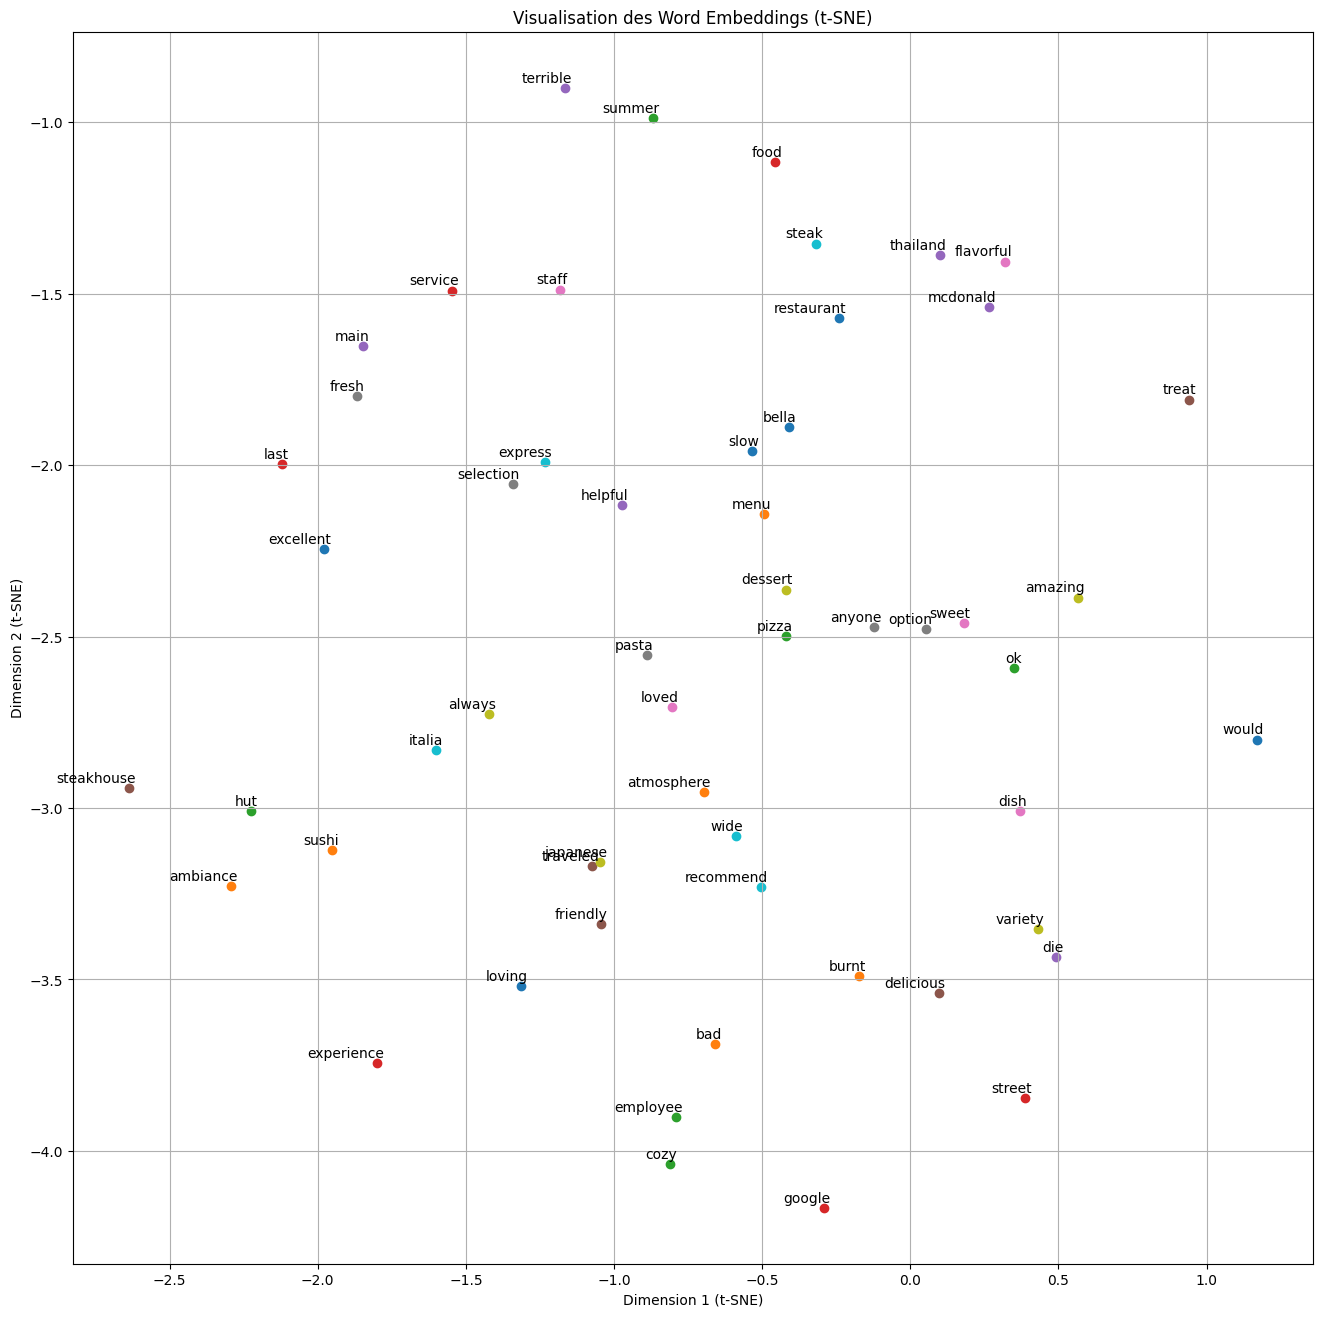


--- Analyse du graphique des plongements de mots ---
**Les mots liés sont-ils proches les uns des autres?**
Sur ce graphique t-SNE, on observe généralement que les mots qui partagent des contextes sémantiques similaires (par exemple, 'food', 'restaurant', 'menu', 'sushi', 'pizza') ont tendance à être regroupés. Cependant, avec un petit corpus comme le nôtre, la qualité des regroupements peut varier et ne pas être aussi distincte qu'avec un corpus plus grand.
**Quelles peuvent être les raisons possibles pour ce résultat?**
1. **Taille du corpus:** Notre dataset est très petit. Les modèles Word2Vec apprennent la signification des mots à partir de leur contexte. Un corpus plus grand et plus varié permettrait au modèle de capturer des relations sémantiques plus riches et plus précises, résultant en des regroupements plus cohérents.
2. **Paramètres du modèle:** Le choix de `vector_size`, `window`, `min_count` et du type d'architecture (CBOW ou Skip-gram) influence fortement le résultat. De

In [70]:
def plot_word_embeddings(model):
    labels = []
    tokens = []

    for word in model.wv.key_to_index:
        tokens.append(model.wv[word])
        labels.append(word)

    # Convertir la liste de vecteurs en un tableau NumPy
    import numpy as np # Importation locale pour cette fonction
    tokens_array = np.array(tokens)

    # Réduire la dimensionnalité à 2D en utilisant t-SNE
    # Utiliser 'max_iter' au lieu de 'n_iter' pour éviter le FutureWarning
    tsne_model = TSNE(perplexity=min(30, len(tokens_array) - 1), n_components=2, init='pca', random_state=42, max_iter=2500)
    new_values = tsne_model.fit_transform(tokens_array)

    x = []
    y = []
    for value in new_values:
        x.append(value[0])
        y.append(value[1])

    plt.figure(figsize=(16, 16))
    for i in range(len(x)):
        plt.scatter(x[i], y[i])
        plt.annotate(labels[i],
                     xy=(x[i], y[i]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom')
    plt.title('Visualisation des Word Embeddings (t-SNE)')
    plt.xlabel('Dimension 1 (t-SNE)')
    plt.ylabel('Dimension 2 (t-SNE)')
    plt.grid(True)
    plt.show()

# Appeler la fonction pour visualiser les embeddings
plot_word_embeddings(word2vec_model)

print("\n--- Analyse du graphique des plongements de mots ---")
print("**Les mots liés sont-ils proches les uns des autres?**")
print("Sur ce graphique t-SNE, on observe généralement que les mots qui partagent des contextes sémantiques similaires (par exemple, 'food', 'restaurant', 'menu', 'sushi', 'pizza') ont tendance à être regroupés. Cependant, avec un petit corpus comme le nôtre, la qualité des regroupements peut varier et ne pas être aussi distincte qu'avec un corpus plus grand.")
print("**Quelles peuvent être les raisons possibles pour ce résultat?**")
print("1. **Taille du corpus:** Notre dataset est très petit. Les modèles Word2Vec apprennent la signification des mots à partir de leur contexte. Un corpus plus grand et plus varié permettrait au modèle de capturer des relations sémantiques plus riches et plus précises, résultant en des regroupements plus cohérents.")
print("2. **Paramètres du modèle:** Le choix de `vector_size`, `window`, `min_count` et du type d'architecture (CBOW ou Skip-gram) influence fortement le résultat. Des ajustements fins pourraient améliorer la qualité des embeddings.")
print("3. **Prétraitement:** Bien que le prétraitement soit essentiel, des choix différents (par exemple, conserver certaines ponctuations, utiliser un stemming différent) pourraient affecter les tokens finaux et donc les embeddings.")
print("4. **Visualisation (t-SNE):** t-SNE est un algorithme de réduction de dimensionnalité non linéaire qui essaie de préserver les distances locales. Les clusters observés sont une projection 2D d'un espace de haute dimension, et cette projection peut parfois introduire des artefacts ou ne pas parfaitement refléter toutes les relations de l'espace original.")


### 3. Suggestions pour améliorer l'analyse

Pour approfondir et améliorer cette analyse, voici quelques pistes:

*   **Expérimenter avec différentes techniques de prétraitement:**
    *   Essayer de ne pas supprimer certains mots-clés qui pourraient être importants pour la sémantique.
    *   Utiliser la suppression des 'contractions' (par exemple, 'don't' devient 'do not').
    *   Considérer la gestion des nombres si pertinent.

*   **Affiner les paramètres du modèle Word2Vec:**
    *   **`vector_size`**: Augmenter ou diminuer la taille des vecteurs (par exemple, 50, 150, 300) pour voir si cela capture mieux les relations.
    *   **`window`**: Ajuster la taille de la fenêtre contextuelle (par exemple, 2, 8, 10). Une fenêtre plus grande capture des relations sémantiques plus générales, une plus petite des relations plus spécifiques.
    *   **`min_count`**: Modifier le seuil de fréquence minimale. Si le corpus est très petit, `min_count=1` est souvent nécessaire pour inclure tous les mots.
    *   **`sg` (Skip-gram vs CBOW)**: Tester l'architecture Skip-gram (`sg=1`) qui est souvent meilleure pour les petits corpus et les mots rares, car elle prédit les mots de contexte à partir d'un mot cible.
    *   **`epochs`**: Augmenter le nombre d'itérations d'entraînement (`epochs`) pour permettre au modèle d'apprendre plus en profondeur.

*   **Explorer des techniques de visualisation avancées pour les plongements de mots:**
    *   Utiliser d'autres algorithmes de réduction de dimensionnalité comme PCA (Principal Component Analysis) pour une comparaison.
    *   Visualiser des sous-ensembles spécifiques de mots (par exemple, seulement les noms de restaurants, les adjectifs de description) pour une analyse plus ciblée.
    *   Utiliser des bibliothèques interactives comme `plotly` ou `bokeh` pour des visualisations 3D ou interactives.
    *   Calculer la similarité cosinus entre les vecteurs de mots pour trouver des mots sémantiquement proches et valider les regroupements visuels.

En appliquant ces suggestions, vous pourrez obtenir des embeddings de mots plus robustes et une meilleure compréhension des relations sémantiques dans votre texte.

In [71]:
# To re-run all cells, simply execute this block, and then use 'Run all' from the Colab menu.
# This will ensure all previous fixes are applied and the notebook state is consistent.

print("Veuillez exécuter toutes les cellules à partir du menu 'Exécuter' -> 'Exécuter tout' pour appliquer les corrections et continuer l'analyse.")


Veuillez exécuter toutes les cellules à partir du menu 'Exécuter' -> 'Exécuter tout' pour appliquer les corrections et continuer l'analyse.
